### Carga de librerías y datos

In [2]:
#Librerías a usar
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#Carga del csv con los datos
file_id = '1EFM-jnbWsT2buCk6NjT_XAffz0oeVyLE'
url = f'https://drive.google.com/uc?id={file_id}'

train=pd.read_csv(url)

#**1. Introducción**

**Pregunta de investigación**

¿Cómo afecta la ubicación y aspectos físicos de una casa en su precio?

**Contexto**

El mercado inmobiliario es uno de los negocios más importantes en el mundo, porque la compra y venta de una vivienda representa una de las mayores decisiones financieras en la vida de una persona Sin embargo, determinar el valor justo de una propiedad no es una tarea tan sencilla, porque intervienen varios factores que van desde las características físicas del inmueble hasta su ubicación geográfica y entorno.

Comprender qué factores impactan en mayor medida el precio de una vivienda resulta importante tanto para compradores que buscan tomar decisiones acertadas, como para vendedores y agentes inmobiliarios que necesitan estimar el valor real de una propiedad.

**Relación entre el problema y la base de datos seleccionada**

El dataset utilizado corresponde a la competencia [House Prices: Advanced Regression Techniques de Kaggle](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques), el cual contiene información detallada de 1,460 viviendas residenciales ubicadas en Ames, Iowa (Estados Unidos). Con 79 variables explicativas, este conjunto de datos registra tanto características físicas de las propiedades como su ubicación y entorno, lo que lo convierte en una fuente ideal para responder la pregunta de investigación planteada.
En cuanto a la ubicación, el dataset incluye variables como el vecindario, el tipo de zona y la proximidad a vías principales o vías férreas. Respecto a los aspectos físicos, cuenta con información sobre el área habitable, la calidad y condición general de la construcción, el número de habitaciones y baños, la antigüedad de la vivienda y la presencia de espacios adicionales como garaje, sótano o porche. La variable objetivo es el precio de venta, lo que permite analizar directamente cómo cada uno de estos factores se relaciona con el valor final de la propiedad.

#**2. Descripción de la base de datos**

-Preview base de datos<br>
-Cantidad de registros y variables<br>
-Variables categóricas y numéricas<br>
-Descripción de variables numéricas


In [3]:
#Preview de la base de datos
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Número de registros y variables
print(f"Número de registros: {train.shape[0]}")
print(f"Número de variables: {train.shape[1]}")

Número de registros: 1460
Número de variables: 81


In [5]:
# Tipos de datos
print("\nTipos de datos por variable:")
print(train.dtypes.value_counts())


Tipos de datos por variable:
object     43
int64      35
float64     3
Name: count, dtype: int64


In [6]:
# Clasificación de variables
categoricas = train.select_dtypes(include=['object']).columns.tolist()
numericas = train.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("🔹 Variables categóricas:")
print("\n".join([f"- {col}" for col in categoricas]))

print("\n🔸 Variables numéricas:")
print("\n".join([f"- {col}" for col in numericas]))


🔹 Variables categóricas:
- MSZoning
- Street
- Alley
- LotShape
- LandContour
- Utilities
- LotConfig
- LandSlope
- Neighborhood
- Condition1
- Condition2
- BldgType
- HouseStyle
- RoofStyle
- RoofMatl
- Exterior1st
- Exterior2nd
- MasVnrType
- ExterQual
- ExterCond
- Foundation
- BsmtQual
- BsmtCond
- BsmtExposure
- BsmtFinType1
- BsmtFinType2
- Heating
- HeatingQC
- CentralAir
- Electrical
- KitchenQual
- Functional
- FireplaceQu
- GarageType
- GarageFinish
- GarageQual
- GarageCond
- PavedDrive
- PoolQC
- Fence
- MiscFeature
- SaleType
- SaleCondition

🔸 Variables numéricas:
- Id
- MSSubClass
- LotFrontage
- LotArea
- OverallQual
- OverallCond
- YearBuilt
- YearRemodAdd
- MasVnrArea
- BsmtFinSF1
- BsmtFinSF2
- BsmtUnfSF
- TotalBsmtSF
- 1stFlrSF
- 2ndFlrSF
- LowQualFinSF
- GrLivArea
- BsmtFullBath
- BsmtHalfBath
- FullBath
- HalfBath
- BedroomAbvGr
- KitchenAbvGr
- TotRmsAbvGrd
- Fireplaces
- GarageYrBlt
- GarageCars
- GarageArea
- WoodDeckSF
- OpenPorchSF
- EnclosedPorch
- 3SsnPorch

In [7]:
# Descripción general
print("\nDescripción de variables numéricas:")
print(train.describe())


Descripción de variables numéricas:
                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     20

#**3. Análisis inicial de variables**

-Conteo de valores y tipos<br>
-Conteo de valores nulos<br>
-Identificación de variables clave


In [10]:
#Conteo de valores y tipos de datos
resumen = pd.DataFrame({
    'Tipo': train.dtypes,
    'Valores Únicos': train.nunique(),
    'Conteo No Nulos': train.count(),
    'Valores Nulos': train.isnull().sum(),
    'Porcentaje Nulos (%)': (train.isnull().sum() / len(train) * 100).round(2)
})

resumen

,Tipo,Valores Únicos,Conteo No Nulos,Valores Nulos,Porcentaje Nulos (%)
Id,int64,1460,1460,0,0.00
MSSubClass,int64,15,1460,0,0.00
MSZoning,object,5,1460,0,0.00
LotFrontage,float64,110,1201,259,17.74
LotArea,int64,1073,1460,0,0.00
...,...,...,...,...,...
MoSold,int64,12,1460,0,0.00
YrSold,int64,5,1460,0,0.00
SaleType,object,9,1460,0,0.00
SaleCondition,object,6,1460,0,0.00


In [12]:
#Solo las variables que tienen valores nulos
resumen_nulos = resumen[resumen['Valores Nulos'] > 0].sort_values('Porcentaje Nulos (%)', ascending=False)

resumen_nulos

,Tipo,Valores Únicos,Conteo No Nulos,Valores Nulos,Porcentaje Nulos (%)
PoolQC,object,3,7,1453,99.52
MiscFeature,object,4,54,1406,96.30
Alley,object,2,91,1369,93.77
Fence,object,4,281,1179,80.75
MasVnrType,object,3,588,872,59.73
FireplaceQu,object,5,770,690,47.26
LotFrontage,float64,110,1201,259,17.74
GarageType,object,6,1379,81,5.55
GarageYrBlt,float64,97,1379,81,5.55
GarageFinish,object,3,1379,81,5.55


<h1><b>Variables clave y su significado</b> </h1>
<div style="font-size: 18px;">
<table style="border-collapse: collapse; width: 100%; font-family: Arial, sans-serif; font-size: 30px;">
  <thead>
    <tr style="background-color: #2c3e50; color: white;">
      <th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Variable</th>
      <th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Eje</th>
      <th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Qué significa</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #d6eaf8;">
      <td style="padding: 10px; border: 1px solid #ddd;"><code>Neighborhood</code></td>
      <td style="padding: 10px; border: 1px solid #ddd;">Ubicación</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Vecindario donde está la casa</td>
    </tr>
    <tr style="background-color: #d6eaf8;">
      <td style="padding: 10px; border: 1px solid #ddd;"><code>MSZoning</code></td>
      <td style="padding: 10px; border: 1px solid #ddd;">Ubicación</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Tipo de zonificación del área</td>
    </tr>
    <tr style="background-color: #d6eaf8;">
      <td style="padding: 10px; border: 1px solid #ddd;"><code>Condition1</code></td>
      <td style="padding: 10px; border: 1px solid #ddd;">Ubicación</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Proximidad a vías o ferrocarril</td>
    </tr>
    <tr style="background-color: #d5f5e3;">
      <td style="padding: 10px; border: 1px solid #ddd;"><code>GrLivArea</code></td>
      <td style="padding: 10px; border: 1px solid #ddd;">Físico</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Área habitable en pies cuadrados</td>
    </tr>
    <tr style="background-color: #d5f5e3;">
      <td style="padding: 10px; border: 1px solid #ddd;"><code>OverallQual</code></td>
      <td style="padding: 10px; border: 1px solid #ddd;">Físico</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Calidad de materiales del 1 al 10</td>
    </tr>
    <tr style="background-color: #d5f5e3;">
      <td style="padding: 10px; border: 1px solid #ddd;"><code>OverallCond</code></td>
      <td style="padding: 10px; border: 1px solid #ddd;">Físico</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Condición actual de la casa del 1 al 10</td>
    </tr>
    <tr style="background-color: #d5f5e3;">
      <td style="padding: 10px; border: 1px solid #ddd;"><code>LotArea</code></td>
      <td style="padding: 10px; border: 1px solid #ddd;">Físico</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Tamaño del terreno en pies cuadrados</td>
    </tr>
    <tr style="background-color: #d5f5e3;">
      <td style="padding: 10px; border: 1px solid #ddd;"><code>TotalBsmtSF</code></td>
      <td style="padding: 10px; border: 1px solid #ddd;">Físico</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Área total del sótano en pies cuadrados</td>
    </tr>
    <tr style="background-color: #d5f5e3;">
      <td style="padding: 10px; border: 1px solid #ddd;"><code>GarageCars</code></td>
      <td style="padding: 10px; border: 1px solid #ddd;">Físico</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Capacidad del garaje en número de carros</td>
    </tr>
    <tr style="background-color: #d5f5e3;">
      <td style="padding: 10px; border: 1px solid #ddd;"><code>FullBath</code></td>
      <td style="padding: 10px; border: 1px solid #ddd;">Físico</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Número de baños completos</td>
    </tr>
    <tr style="background-color: #d5f5e3;">
      <td style="padding: 10px; border: 1px solid #ddd;"><code>BedroomAbvGr</code></td>
      <td style="padding: 10px; border: 1px solid #ddd;">Físico</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Número de habitaciones sobre el suelo</td>
    </tr>
    <tr style="background-color: #fdebd0;">
      <td style="padding: 10px; border: 1px solid #ddd;"><code>SalePrice</code></td>
      <td style="padding: 10px; border: 1px solid #ddd;">Objetivo</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Precio de venta en dólares</td>
    </tr>
  </tbody>
</table>

In [17]:
#Variables clave enfocadas a nuestra pregunta de investigación
variables_clave = ['Neighborhood', 'MSZoning', 'Condition1',
                   'GrLivArea', 'OverallQual', 'OverallCond',
                   'LotArea', 'TotalBsmtSF', 'GarageCars',
                   'FullBath', 'BedroomAbvGr', 'SalePrice']

df = train[variables_clave]

# Verificar
print(df.shape)
df.head()

(1460, 12)


,Neighborhood,MSZoning,Condition1,GrLivArea,OverallQual,OverallCond,LotArea,TotalBsmtSF,GarageCars,FullBath,BedroomAbvGr,SalePrice
0,CollgCr,RL,Norm,1710,7,5,8450,856,2,2,3,208500
1,Veenker,RL,Feedr,1262,6,8,9600,1262,2,2,3,181500
2,CollgCr,RL,Norm,1786,7,5,11250,920,2,2,3,223500
3,Crawfor,RL,Norm,1717,7,5,9550,756,3,1,3,140000
4,NoRidge,RL,Norm,2198,8,5,14260,1145,3,2,4,250000


In [18]:
#Descripciones de las variables clave numéricas
print("\nDescripción de variables clave:")
print(df.describe())


Descripción de variables clave:
         GrLivArea  OverallQual  OverallCond        LotArea  TotalBsmtSF  \
count  1460.000000  1460.000000  1460.000000    1460.000000  1460.000000   
mean   1515.463699     6.099315     5.575342   10516.828082  1057.429452   
std     525.480383     1.382997     1.112799    9981.264932   438.705324   
min     334.000000     1.000000     1.000000    1300.000000     0.000000   
25%    1129.500000     5.000000     5.000000    7553.500000   795.750000   
50%    1464.000000     6.000000     5.000000    9478.500000   991.500000   
75%    1776.750000     7.000000     6.000000   11601.500000  1298.250000   
max    5642.000000    10.000000     9.000000  215245.000000  6110.000000   

        GarageCars     FullBath  BedroomAbvGr      SalePrice  
count  1460.000000  1460.000000   1460.000000    1460.000000  
mean      1.767123     1.565068      2.866438  180921.195890  
std       0.747315     0.550916      0.815778   79442.502883  
min       0.000000     0.00000

In [15]:
#Resumen de las variables clave
resumen_clave = pd.DataFrame({
    'Tipo': df.dtypes,
    'Valores Únicos': df.nunique(),
    'Valores Nulos': df.isnull().sum()
})

resumen_clave

,Tipo,Valores Únicos,Valores Nulos
Neighborhood,object,25,0
MSZoning,object,5,0
Condition1,object,9,0
GrLivArea,int64,861,0
OverallQual,int64,10,0
OverallCond,int64,9,0
LotArea,int64,1073,0
TotalBsmtSF,int64,721,0
GarageCars,int64,5,0
FullBath,int64,4,0


#**4. Visualizaciones**

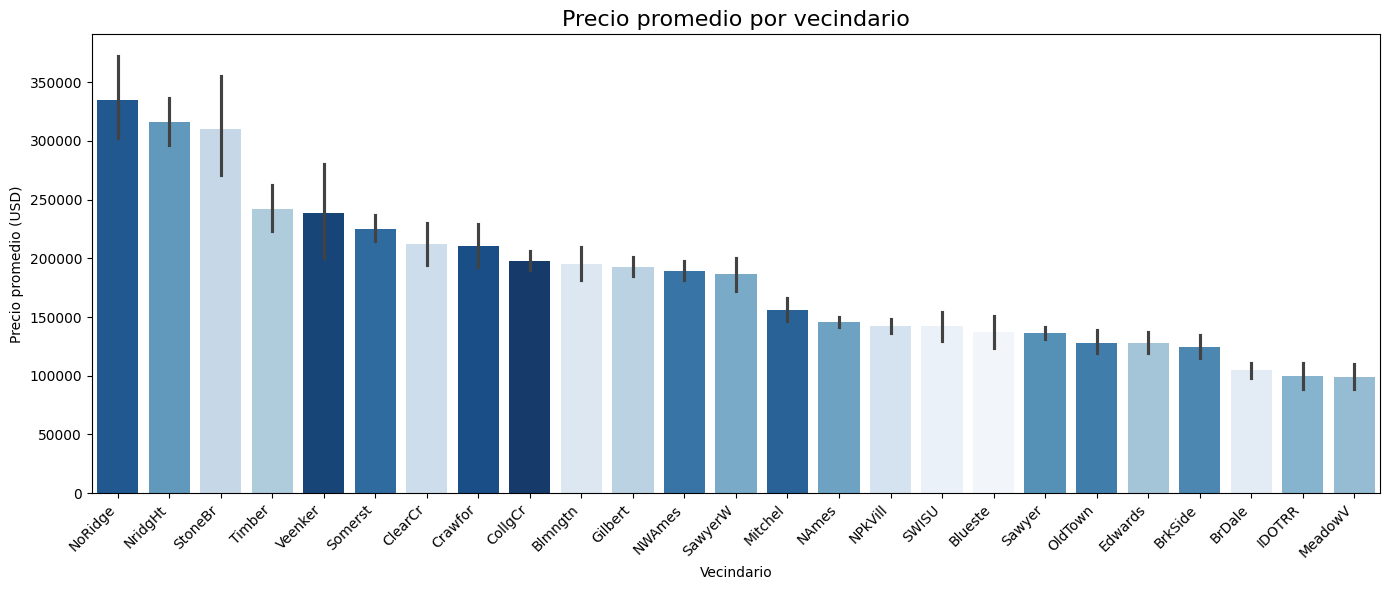

In [20]:
#1. Precio promedio por vecindario
plt.figure(figsize=(14, 6))
orden = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='Neighborhood', y='SalePrice', order=orden, hue='Neighborhood', palette='Blues_r',legend=False)
plt.title('Precio promedio por vecindario', fontsize=16)
plt.xlabel('Vecindario')
plt.ylabel('Precio promedio (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

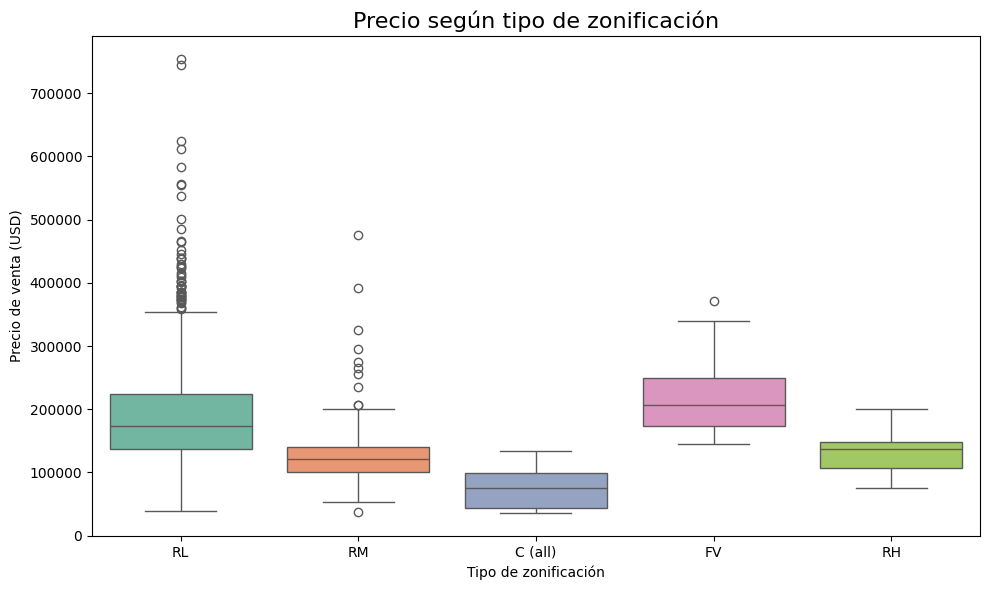

In [22]:
#2. Precio según tipo de zonificación
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='MSZoning', y='SalePrice', hue='MSZoning', palette='Set2', legend=False)
plt.title('Precio según tipo de zonificación', fontsize=16)
plt.xlabel('Tipo de zonificación')
plt.ylabel('Precio de venta (USD)')
plt.tight_layout()
plt.show()

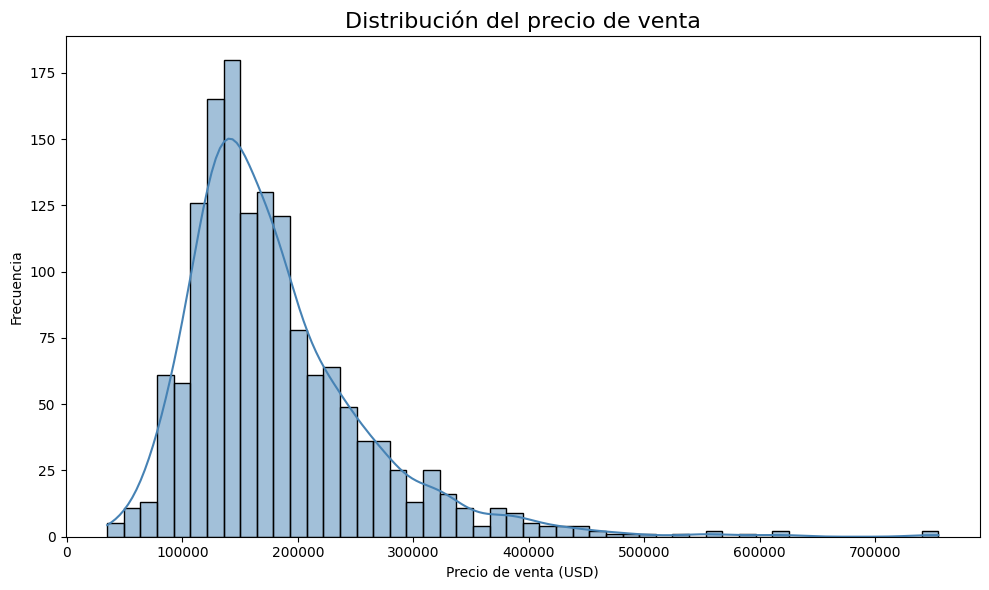

In [23]:
#3.Distribución del precio de venta
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], bins=50, kde=True, color='steelblue')
plt.title('Distribución del precio de venta', fontsize=16)
plt.xlabel('Precio de venta (USD)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

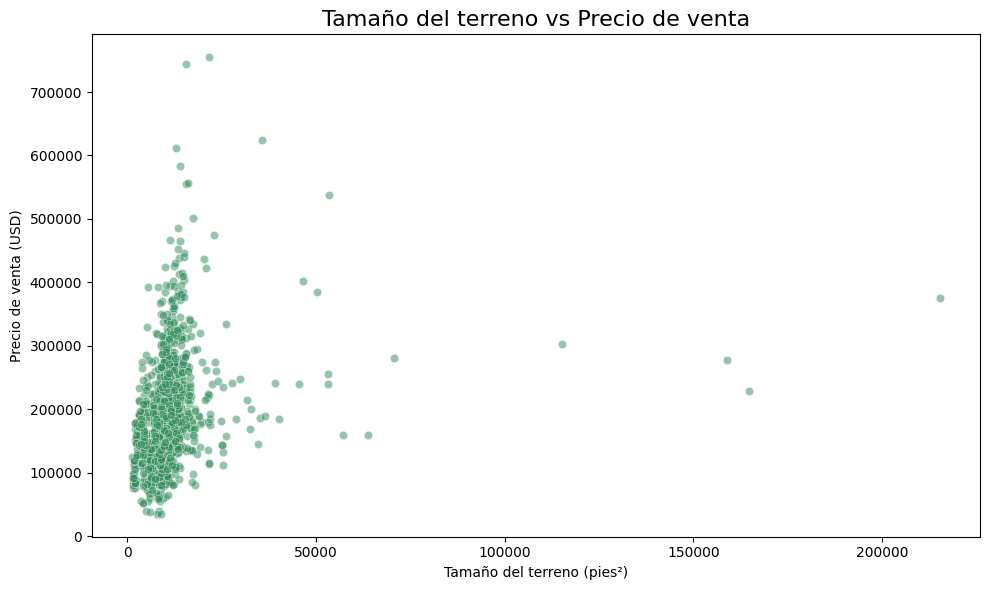

In [24]:
#4. Tamaño del terreno vs Precio
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='LotArea', y='SalePrice', alpha=0.5, color='seagreen')
plt.title('Tamaño del terreno vs Precio de venta', fontsize=16)
plt.xlabel('Tamaño del terreno (pies²)')
plt.ylabel('Precio de venta (USD)')
plt.tight_layout()
plt.show()

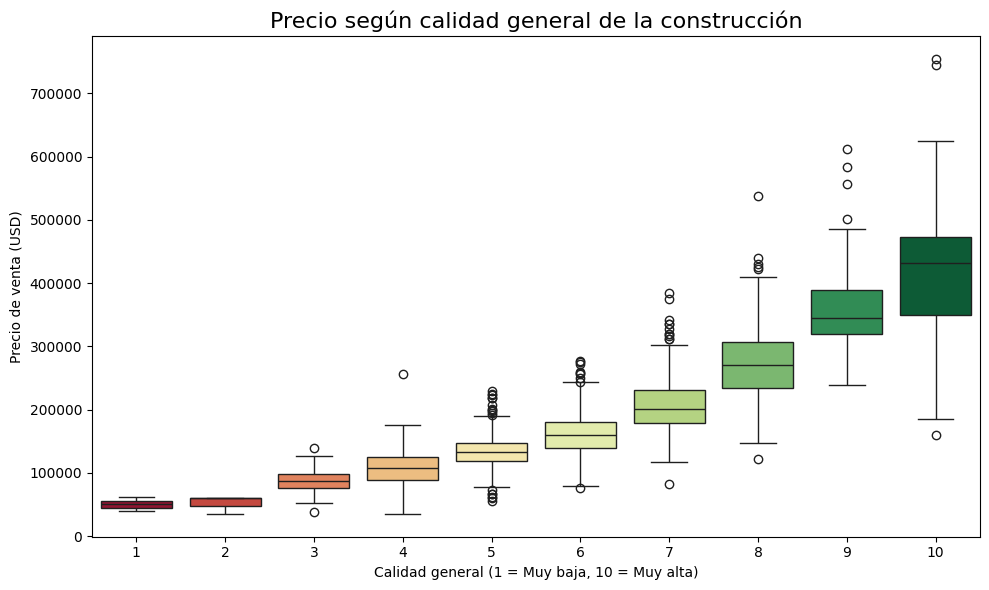

In [26]:
#5. Precio según calidad general
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='OverallQual', y='SalePrice', hue='OverallQual',legend=False,palette='RdYlGn')
plt.title('Precio según calidad general de la construcción', fontsize=16)
plt.xlabel('Calidad general (1 = Muy baja, 10 = Muy alta)')
plt.ylabel('Precio de venta (USD)')
plt.tight_layout()
plt.show()

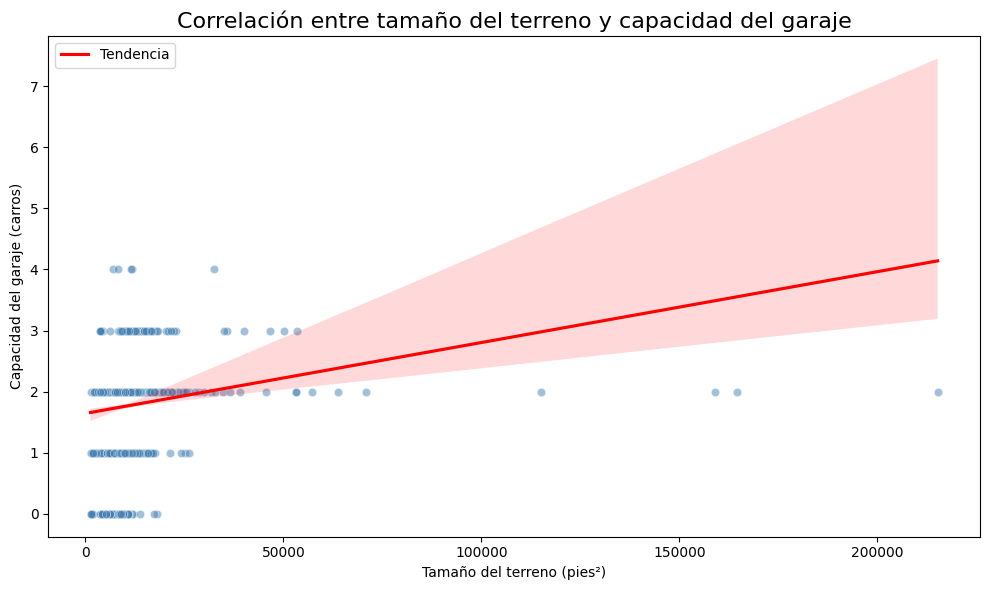

Coeficiente de correlación: 0.1549


In [27]:
#Correlación entre LotArea y GarageCars
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='LotArea', y='GarageCars', alpha=0.5, color='steelblue')
sns.regplot(data=df, x='LotArea', y='GarageCars', scatter=False, color='red', label='Tendencia')
plt.title('Correlación entre tamaño del terreno y capacidad del garaje', fontsize=16)
plt.xlabel('Tamaño del terreno (pies²)')
plt.ylabel('Capacidad del garaje (carros)')
plt.legend()
plt.tight_layout()
plt.show()

# Valor numérico de la correlación
correlacion = df['LotArea'].corr(df['GarageCars'])
print(f'Coeficiente de correlación: {correlacion:.4f}')

#**5.Interpretaciones iniciales**

<div style="font-family: Arial, sans-serif; font-size: 16px; line-height: 1.6;">

  <h2 style="color: #2c3e50;">Tendencias y patrones observados</h2>
  <ul>
    <li>Los precios varían considerablemente entre vecindarios, con una diferencia notable entre los extremos.</li>
    <li>Algunos vecindarios como StoneBr muestran barras de error grandes, indicando precios muy variables internamente.</li>
    <li>FV y RL tienen precios medianos más altos que las demás zonas.</li>
    <li>C (all) presenta los precios más bajos y con menos variación.</li>
    <li>RL tiene varios valores atípicos hacia arriba, sugiriendo presencia de propiedades de lujo.</li>
    <li>RH y RM se comportan de forma similar en rango de precios.</li>
    <li>La mayoría de casas se venden entre $100,000 y $200,000 USD.</li>
    <li>La distribución está sesgada hacia la derecha.</li>
    <li>No se observa una tendencia clara y lineal entre el tamaño del terreno y el precio.</li>
    <li>Existen varios valores atípicos con terrenos muy grandes que no necesariamente tienen precios altos.</li>
    <li>Se observa una tendencia creciente muy clara: a mayor calidad, mayor precio.</li>
    <li>La línea de tendencia entre la capacidad del garaje y el tamaño del terreno sube ligeramente, pero la banda de confianza es muy amplia, lo que indica que la relación entre ambas variables es débil e imprecisa.</li>
    <li>La mayoría de casas tienen garaje para 1 o 2 carros independientemente del tamaño del terreno.</li>
  </ul>

  <h2 style="color: #2c3e50;">Limitaciones de la base de datos</h2>
  <ul>
    <li>Los datos corresponden únicamente a Ames, Iowa, lo que limita su generalización a otros mercados inmobiliarios.</li>
    <li>Algunas variables como <code>GarageCars</code> o <code>FullBath</code> son enteros discretos que no capturan matices de calidad.</li>
    <li>No se incluye información sobre el entorno socioeconómico del vecindario más allá del nombre.</li>
    <li>Los precios no están ajustados por inflación, ya que el dataset abarca varios años de ventas.</li>
    <li>La calidad general (<code>OverallQual</code>) es una calificación subjetiva asignada por un evaluador, lo que puede introducir sesgo humano.</li>
    <li>Los terrenos muy grandes son muy pocos en el dataset, lo que hace poco representativa esa franja del análisis.</li>


  </ul>

  <h2 style="color: #2c3e50;">¿Qué hipótesis iniciales se pueden plantear?</h2>
  <ul>
    <li>Los vecindarios con mayor prestigio o mejor ubicación tendrán precios significativamente más altos.</li>
    <li>A mayor área habitable, mayor será el precio de venta de la vivienda.</li>
    <li>Las casas con mejor calidad general de construcción tendrán precios más altos independientemente del vecindario.</li>
    <li>El tamaño del terreno tendrá una correlación positiva pero moderada con el precio, ya que no garantiza mayor área construida.</li>
    <li>Existirá una correlación más fuerte entre el área habitable y el precio que entre el tamaño del terreno y el precio.</li>
    <li>La calidad general de construcción será una de las variables con mayor correlación con el precio de venta.</li>


  </ul>

</div>

#**6. Conclusiones**

<div style="font-family: Arial, sans-serif; font-size: 16px; line-height: 1.6;">

  <h2 style="color: #2c3e50;">6. Conclusiones</h2>

  <h3 style="color: #2980b9;">Resumen de los principales hallazgos iniciales</h3>
  <ul>
    <li>El vecindario donde se ubica una propiedad tiene un impacto muy significativo en su precio, con diferencias de más del triple entre los vecindarios más costosos y los más económicos.</li>
    <li>La zonificación del área también influye en el valor de la vivienda, siendo las zonas residenciales de baja densidad y las zonas planificadas las que concentran los precios más altos a diferencia por ejemplo de las zonas comerciales.</li>
    <li>La calidad general de construcción mostró ser la variable física con la relación más clara y consistente con el precio de venta, evidenciando una tendencia creciente a lo largo de todos sus niveles.</li>
    <li>La distribución del precio de venta presenta un sesgo hacia la derecha, con la mayoría de propiedades concentradas entre $100,000 y $200,000 USD y una minoría de viviendas de lujo que elevan la media.</li>
    <li>El tamaño del terreno mostró una relación débil con el precio, sugiriendo que por sí solo no es un factor determinante del valor de una propiedad.</li>
  </ul>

  <h3 style="color: #2980b9;">Reflexión sobre cómo este entregable contribuye al desarrollo del proyecto completo</h3>
  <p>
    Este primer laboratorio establece las bases del análisis al permitir comprender la estructura del dataset, identificar las variables más relevantes para la pregunta de investigación y detectar patrones iniciales en los datos. Los hallazgos obtenidos en esta etapa exploratoria permiten confirmar algunas hipótesis planteadas, como la fuerte influencia de la calidad de construcción y la ubicación en el precio, y descartar otras, como la relevancia del tamaño del terreno como variable independiente. En las siguientes fases del proyecto, estos resultados servirán como punto de partida para realizar análisis más profundos, como correlaciones estadísticas, tratamiento de valores atípicos, y todo el procesado de los datos como limpieza, normalización, etc.
  </p>

</div>

#**7.Referencias**

<div style="font-family: Arial, sans-serif; font-size: 16px; line-height: 1.6;">

  <h3 style="color: #2980b9;">Fuente de los datos</h3>
  <ul>
    <li>
      <strong>Dataset:</strong> House Prices - Advanced Regression Techniques<br>
      <strong>Repositorio:</strong> Kaggle Competitions<br>
      <strong>Autores:</strong> Anna Montoya, DataCanary<br>
      <strong>Descripción:</strong> Datos de ventas residenciales de la ciudad de Ames, Iowa (EE.UU.), con 79 variables que describen características físicas, de ubicación y condición de las propiedades, junto con su precio de venta final.<br>
      <strong>Enlace:</strong> <a href="https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data?select=data_description.txt" target="_blank">kaggle.com - House Prices Dataset</a>
    </li>
  </ul>

</div>